<a href="https://colab.research.google.com/github/andrew-jordan-spbu/medical-cv-project/blob/colab/skin_disease_classification_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Классификация кожных заболеваний (HAM10000) — Colab-версия

Этот ноутбук адаптирован под Google Colab: качает данные с Kaggle, использует GPU Colab и повторяет полный пайплайн (подготовка данных, обучение EfficientNet-B0, метрики и визуализация).


## Как запускать в Colab

1. Вставьте Kaggle API ключ: в браузере Kaggle → Settings → Create API Token, загрузите `kaggle.json`.
2. В Colab загрузите файл через панель "Files" и положите в `~/.kaggle/kaggle.json` (код ниже делает это автоматически).
3. Запустите ячейки по порядку. GPU выбирается в меню Runtime → Change runtime type → GPU.
4. 3 эпохи на T4/V100 занимают ~5–8 минут.


In [ ]:
# Установка зависимостей для Colab (CUDA 12.1 сборка PyTorch, если доступен GPU)
!pip install -q --upgrade pip
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install -q pandas numpy scikit-learn matplotlib seaborn kaggle tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 25.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Tuple, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm

# Проверяем доступность GPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используем устройство: {DEVICE}")


Используем устройство: cuda


In [ ]:
# Вспомогательные функции из dl101: детерминированные сиды и подсчёт параметров

def seed_everything(seed: int = 314159, torch_deterministic: bool = False) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.use_deterministic_algorithms(torch_deterministic)


def count_pytorch_model_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [ ]:
# Простой сохранитель чекпоинтов по лучшей метрике (адаптация из dl101)
from dataclasses import dataclass
from pathlib import Path
import shutil

@dataclass
class Checkpoint:
    metric_val: float
    epoch: int
    save_path: Path

class CheckpointSaver:
    def __init__(self, model: nn.Module, metric_name: str, save_dir: Path, max_history: int = 1, minimize: bool = False):
        self.model = model
        self.metric_name = metric_name
        self.save_dir = save_dir
        self.max_history = max_history
        self.minimize = minimize  # для метрик типа loss используем True, для F1/accuracy — False
        self._storage: list[Checkpoint] = []
        self.save_dir.mkdir(parents=True, exist_ok=True)

    def save(self, metric_val: float, epoch: int) -> None:
        save_path = self.save_dir / f"model_e{epoch:03d}.pth"
        torch.save({"epoch": epoch, "model_state_dict": self.model.state_dict()}, save_path)
        self._storage.append(Checkpoint(metric_val=metric_val, epoch=epoch, save_path=save_path))
        self._storage = sorted(self._storage, key=lambda x: x.metric_val, reverse=not self.minimize)
        if len(self._storage) > self.max_history:
            worst = self._storage.pop()
            worst.save_path.unlink(missing_ok=True)
        # дублируем лучший в фиксированное имя
        best_path = self.save_dir / "model_best.pth"
        shutil.copyfile(self._storage[0].save_path, best_path)



In [ ]:
# Настройки проекта
@dataclass
class Config:
    project_root: Path = Path("/content/skin_ham10000")  # куда сложим данные/модель в Colab
    kaggle_dataset: str = "kmader/skin-cancer-mnist-ham10000"
    image_size: int = 224
    batch_size: int = 32
    num_workers: int = 2
    lr: float = 1e-3
    weight_decay: float = 1e-4
    # Адаптивное число эпох: min_epochs обязательно, max_epochs верхняя граница,
    # patience — сколько эпох без улучшения макро-F1 ждём перед остановкой,
    # target_f1 — если достигли, завершаем раньше.
    min_epochs: int = 4
    max_epochs: int = 30
    patience: int = 3
    target_f1: float | None = 0.90   # целимcя в высокий macro-F1
    target_acc: float | None = 0.95  # целевая accuracy
    val_size: float = 0.15
    seed: int = 42

cfg = Config()
cfg.project_root.mkdir(parents=True, exist_ok=True)
print(cfg)


Config(project_root=PosixPath('/content/skin_ham10000'), kaggle_dataset='kmader/skin-cancer-mnist-ham10000', image_size=224, batch_size=32, num_workers=2, lr=0.001, weight_decay=0.0001, min_epochs=4, max_epochs=30, patience=3, target_f1=0.9, target_acc=0.95, val_size=0.15, seed=42)


In [ ]:
#Кладём kaggle.json в ~/.kaggle и ставим права 600 (как требует Kaggle API)
#В Colab: загрузите kaggle.json через панель Files, затем выполните эту ячейку.
from pathlib import Path
from kaggle.api.kaggle_api_extended import KaggleApi

kaggle_dir = Path("/root/.config/kaggle")
kaggle_dir.mkdir(parents=True, exist_ok=True)

#Если kaggle.json уже загружен в файловую систему Colab (например, в /content/kaggle.json), переместим его
Path("/content/kaggle.json").replace(kaggle_dir / "kaggle.json")

!chmod 600 /root/.config/kaggle/kaggle.json
print("kaggle.json настроен")

kaggle.json настроен


In [ ]:
# Скачиваем и распаковываем HAM10000 из Kaggle
import zipfile
api = KaggleApi()
api.authenticate()

data_dir = cfg.project_root / "raw"
images_dir = data_dir / "images"
metadata_path = data_dir / "HAM10000_metadata.csv"

data_dir.mkdir(parents=True, exist_ok=True)

if not metadata_path.exists():
    print("Скачиваем архив...")
    api.dataset_download_files(cfg.kaggle_dataset, path=data_dir, quiet=False, unzip=True)
else:
    print("Файлы уже скачаны, пропускаем загрузку.")

# Объединяем обе части изображений в одну папку images
if not images_dir.exists():
    images_dir.mkdir(parents=True, exist_ok=True)
    for part in ["HAM10000_images_part_1", "HAM10000_images_part_2"]:
        part_dir = data_dir / part
        if part_dir.exists():
            for img_file in part_dir.glob("*.jpg"):
                target = images_dir / img_file.name
                if not target.exists():
                    img_file.replace(target)
    print(f"Объединены изображения в {images_dir}")
else:
    print("Папка с изображениями уже готова (raw/images).")


Скачиваем архив...
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000


100%|██████████| 5.20G/5.20G [01:43<00:00, 54.2MB/s]



Объединены изображения в /content/skin_ham10000/raw/images


In [ ]:
# Считаем веса классов для сбалансированной функции потерь (полезно для дисбаланса)
# Если metadata/classes ещё не определены (ячейка выше не выполнена), загружаем их здесь.
from collections import Counter

if "metadata" not in globals():
    metadata = pd.read_csv(metadata_path)
    metadata["path"] = metadata["image_id"].apply(lambda x: images_dir / f"{x}.jpg")
    metadata = metadata.rename(columns={"dx": "label"})
if "classes" not in globals():
    classes = sorted(metadata["label"].unique())

label_counts = Counter(metadata["label"])
class_to_idx = {c: i for i, c in enumerate(classes)}
counts = np.array([label_counts[c] for c in classes], dtype=np.float32)
class_weights = counts.sum() / (len(classes) * counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print("Class weights:", class_weights)


Class weights: [ 4.375273   2.783491   1.3018328 12.440994   1.2854576  0.2133802
 10.075453 ]


In [ ]:
# Читаем метаданные и добавляем путь к файлам
metadata = pd.read_csv(metadata_path)
metadata["path"] = metadata["image_id"].apply(lambda x: images_dir / f"{x}.jpg")

missing = metadata[~metadata["path"].apply(lambda p: p.exists())]
print(f"Отсутствующих файлов: {len(missing)}")

metadata = metadata.rename(columns={"dx": "label"})
classes = sorted(metadata["label"].unique())
print(f"Классы ({len(classes)}): {classes}")


Отсутствующих файлов: 0
Классы (7): ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [ ]:
# Разделяем train/val и задаём аугментации

# Сид задаём один раз (функция выше)
seed_everything(cfg.seed)

train_df, val_df = train_test_split(
    metadata,
    test_size=cfg.val_size,
    stratify=metadata["label"],
    random_state=cfg.seed,
)
print(f"Train: {len(train_df)}, Val: {len(val_df)}")

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((cfg.image_size + 32, cfg.image_size + 32)),
    transforms.RandomResizedCrop(cfg.image_size, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

val_transform = transforms.Compose([
    transforms.Resize((cfg.image_size, cfg.image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

class SkinDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.class_to_idx = {c: i for i, c in enumerate(sorted(self.df["label"].unique()))}
        self.idx_to_class = {v: k for k, v in self.class_to_idx.items()}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = self.class_to_idx[row["label"]]
        return image, label

train_dataset = SkinDataset(train_df, transform=train_transform)
val_dataset = SkinDataset(val_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers)
val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

print(f"Пример: {len(train_dataset)} train, {len(val_dataset)} val")


Train: 8512, Val: 1503
Пример: 8512 train, 1503 val


In [ ]:
# Модель: EfficientNet-B0 с предобучением на ImageNet
num_classes = len(classes)
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
# lr scheduler из dl101: реагирует на плато макро-F1 (максимизируем)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)

# чекпоинтер: сохраняем топ-3 модели по val_f1
checkpointer = CheckpointSaver(model, metric_name="val_f1", save_dir=cfg.project_root / "checkpoints", max_history=3, minimize=False)

print(model.classifier)
print(f"Trainable params: {count_pytorch_model_params(model):,}")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 157MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=7, bias=True)
)
Trainable params: 4,016,515


In [ ]:
# Переопределяем лосс и оптимизатор с учетом весов классов (добавлено для цели 95% acc)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)
checkpointer = CheckpointSaver(model, metric_name="val_f1", save_dir=cfg.project_root / "checkpoints", max_history=3, minimize=False)
print("Loss/optimizer переопределены с учётом весов классов")


Loss/optimizer переопределены с учётом весов классов


In [ ]:
# Расширенная версия train_model с целями по F1 и accuracy

def train_model_adaptive(
    model,
    train_loader,
    val_loader,
    min_epochs: int,
    max_epochs: int,
    patience: int,
    target_f1: float | None = None,
    target_acc: float | None = None,
    scheduler=None,
    checkpointer: CheckpointSaver | None = None,
):
    history = []
    best_f1 = -1.0
    best_state = None
    epochs_since_best = 0

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc, train_f1 = run_epoch(train_loader, model, criterion, optimizer)
        val_loss, val_acc, val_f1 = run_epoch(val_loader, model, criterion)
        if scheduler is not None:
            scheduler.step(val_f1)

        history.append({"epoch": epoch, "train_loss": train_loss, "train_acc": train_acc, "train_f1": train_f1,
                        "val_loss": val_loss, "val_acc": val_acc, "val_f1": val_f1})
        print(f"Эпоха {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.3f}, val_f1={val_f1:.3f}")

        improved = val_f1 > best_f1 + 1e-4
        if improved:
            best_f1 = val_f1
            best_state = model.state_dict()
            epochs_since_best = 0
        else:
            epochs_since_best += 1

        if checkpointer is not None:
            checkpointer.save(metric_val=val_f1, epoch=epoch)

        hit_target_f1 = target_f1 is not None and val_f1 >= target_f1
        hit_target_acc = target_acc is not None and val_acc >= target_acc
        if epoch >= min_epochs and (hit_target_f1 or hit_target_acc):
            print(f"Достигли целевой метрики (F1>={target_f1}, acc>={target_acc}) на эпохе {epoch}, останавливаемся.")
            break
        if epoch >= min_epochs and epochs_since_best >= patience:
            print(f"Нет улучшений {patience} эпох после минимальных {min_epochs}, ранняя остановка.")
            break

    if best_state:
        model.load_state_dict(best_state)
    return history


In [ ]:
# Функции обучения/валидации

def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    all_preds, all_targets = [], []
    running_loss = 0.0

    for images, targets in tqdm(loader, desc="train" if is_train else "val", leave=False):
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        with torch.set_grad_enabled(is_train):
            outputs = model(images)
            loss = criterion(outputs, targets)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average="macro")
    return epoch_loss, acc, f1


def train_model(
    model,
    train_loader,
    val_loader,
    min_epochs: int,
    max_epochs: int,
    patience: int,
    target_f1: float | None = None,
    scheduler=None,
    checkpointer: CheckpointSaver | None = None,
):
    history = []
    best_f1 = -1.0
    best_state = None
    epochs_since_best = 0

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc, train_f1 = run_epoch(train_loader, model, criterion, optimizer)
        val_loss, val_acc, val_f1 = run_epoch(val_loader, model, criterion)
        if scheduler is not None:
            scheduler.step(val_f1)

        history.append({"epoch": epoch, "train_loss": train_loss, "train_acc": train_acc, "train_f1": train_f1,
                        "val_loss": val_loss, "val_acc": val_acc, "val_f1": val_f1})
        print(f"Эпоха {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.3f}, val_f1={val_f1:.3f}")

        improved = val_f1 > best_f1 + 1e-4
        if improved:
            best_f1 = val_f1
            best_state = model.state_dict()
            epochs_since_best = 0
        else:
            epochs_since_best += 1

        if checkpointer is not None:
            checkpointer.save(metric_val=val_f1, epoch=epoch)

        # Критерии остановки: достигли цели или patience после min_epochs
        if target_f1 is not None and val_f1 >= target_f1 and epoch >= min_epochs:
            print(f"Достигли целевого F1={target_f1:.3f} на эпохе {epoch}, останавливаемся.")
            break
        if epoch >= min_epochs and epochs_since_best >= patience:
            print(f"Нет улучшений {patience} эпох после минимальных {min_epochs}, ранняя остановка.")
            break

    # Восстанавливаем лучшую версию
    if best_state:
        model.load_state_dict(best_state)
    return history



In [ ]:
# Запускаем обучение с адаптивным числом эпох и целями по F1/Accuracy
history = train_model_adaptive(
    model,
    train_loader,
    val_loader,
    min_epochs=cfg.min_epochs,
    max_epochs=cfg.max_epochs,
    patience=cfg.patience,
    target_f1=cfg.target_f1,
    target_acc=cfg.target_acc,
    scheduler=scheduler,
    checkpointer=checkpointer,
)

history_df = pd.DataFrame(history)
history_df


Эпоха 1: train_loss=1.3547, val_loss=1.2186, val_acc=0.380, val_f1=0.401


Эпоха 2: train_loss=0.9867, val_loss=0.9516, val_acc=0.600, val_f1=0.477


Эпоха 3: train_loss=0.8644, val_loss=0.8144, val_acc=0.645, val_f1=0.614


Эпоха 4: train_loss=0.7800, val_loss=0.8840, val_acc=0.723, val_f1=0.634


Эпоха 5: train_loss=0.6988, val_loss=0.7065, val_acc=0.700, val_f1=0.671


Эпоха 6: train_loss=0.6915, val_loss=0.7024, val_acc=0.772, val_f1=0.656


Эпоха 7: train_loss=0.6221, val_loss=0.7747, val_acc=0.713, val_f1=0.596


Эпоха 8: train_loss=0.4580, val_loss=0.7641, val_acc=0.729, val_f1=0.668
Нет улучшений 3 эпох после минимальных 4, ранняя остановка.


,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
0,1,1.354678,0.539474,0.364698,1.218550,0.379907,0.401237
1,2,0.986654,0.624178,0.483175,0.951579,0.600133,0.476612
2,3,0.864409,0.666118,0.531619,0.814370,0.645376,0.613926
3,4,0.779994,0.693609,0.576123,0.884026,0.723220,0.634119
4,5,0.698789,0.709234,0.599706,0.706523,0.699933,0.670744
5,6,0.691458,0.707472,0.608333,0.702366,0.771790,0.656499
6,7,0.622096,0.730263,0.635595,0.774746,0.712575,0.596153
7,8,0.458005,0.768327,0.710820,0.764052,0.729208,0.667509


In [ ]:
# Обучаем модель: адаптивное число эпох с ранней остановкой, чекпоинтер и ReduceLROnPlateau
history = train_model(
    model,
    train_loader,
    val_loader,
    min_epochs=cfg.min_epochs,
    max_epochs=cfg.max_epochs,
    patience=cfg.patience,
    target_f1=cfg.target_f1,
    scheduler=scheduler,
    checkpointer=checkpointer,
)

history_df = pd.DataFrame(history)
history_df


Эпоха 1: train_loss=0.3857, val_loss=0.5162, val_acc=0.800, val_f1=0.732


Эпоха 2: train_loss=0.3403, val_loss=0.6031, val_acc=0.773, val_f1=0.744


Эпоха 3: train_loss=0.3015, val_loss=0.5592, val_acc=0.834, val_f1=0.793


Эпоха 4: train_loss=0.2737, val_loss=0.5276, val_acc=0.790, val_f1=0.736


Эпоха 5: train_loss=0.3378, val_loss=0.6156, val_acc=0.812, val_f1=0.716


...

Эпоха 14: train_loss=0.1252, val_loss=0.6345, val_acc=0.858, val_f1=0.822


Эпоха 15: train_loss=0.1121, val_loss=0.6101, val_acc=0.840, val_f1=0.820


Эпоха 16: train_loss=0.0972, val_loss=0.6811, val_acc=0.848, val_f1=0.812


Эпоха 17: train_loss=0.0740, val_loss=0.7436, val_acc=0.862, val_f1=0.818
Нет улучшений 3 эпох после минимальных 4, ранняя остановка.


,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
0,1,0.385700,0.792646,0.750535,0.516186,0.799734,0.731597
1,2,0.340337,0.812500,0.774147,0.603129,0.773120,0.744210
2,3,0.301524,0.829182,0.815356,0.559240,0.833666,0.792805
3,4,0.273737,0.835879,0.828613,0.527555,0.789754,0.736252
4,5,0.337754,0.828008,0.786719,0.615626,0.811710,0.716165
5,6,0.245413,0.851034,0.825375,0.498673,0.804391,0.796437
6,7,0.186202,0.872415,0.873732,0.567370,0.813706,0.779746
7,8,0.181452,0.881109,0.881356,0.583541,0.841650,0.802434
8,9,0.145614,0.898966,0.900699,0.636053,0.827678,0.807840
9,10,0.135733,0.896852,0.903036,0.583980,0.831670,0.805768


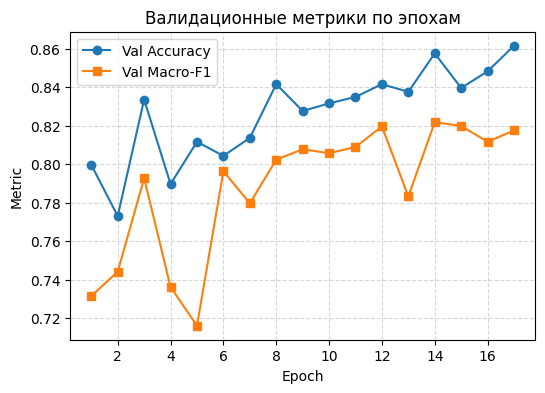

In [ ]:
# График зависимости точности от количества эпох (валидация)
if len(history_df):
    plt.figure(figsize=(6,4))
    plt.plot(history_df["epoch"], history_df["val_acc"], marker="o", label="Val Accuracy")
    plt.plot(history_df["epoch"], history_df["val_f1"], marker="s", label="Val Macro-F1")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    plt.title("Валидационные метрики по эпохам")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
else:
    print("История обучения пуста — проверьте запуск предыдущей ячейки.")


Валидация: accuracy=0.862, macro-F1=0.818
              precision    recall  f1-score   support

       akiec       0.82      0.67      0.74        49
         bcc       0.83      0.82      0.82        77
         bkl       0.70      0.81      0.75       165
          df       0.94      0.94      0.94        17
         mel       0.61      0.69      0.65       167
          nv       0.95      0.91      0.93      1006
        vasc       0.84      0.95      0.89        22

    accuracy                           0.86      1503
   macro avg       0.81      0.83      0.82      1503
weighted avg       0.87      0.86      0.86      1503



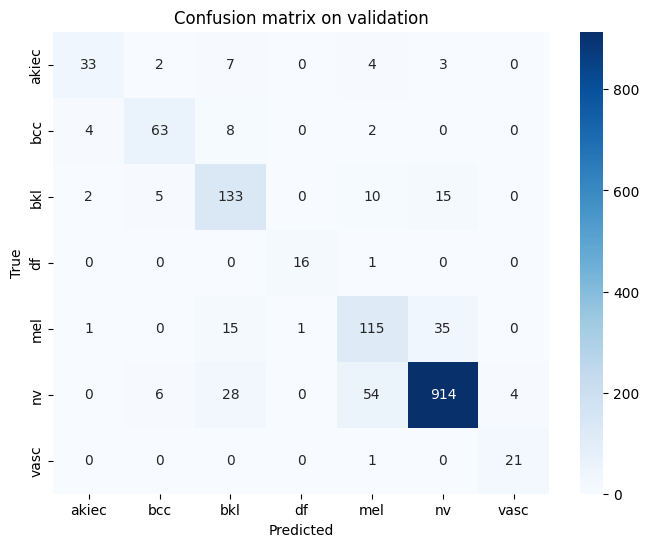

Модель сохранена: /content/skin_ham10000/efficientnet_b0_ham10000.pth


In [ ]:
# Оценка на валидации

def predict(loader, model):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for images, targets in tqdm(loader, desc="predict", leave=False):
            images = images.to(DEVICE)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(targets.numpy())
    return np.array(all_preds), np.array(all_targets)

val_preds, val_targets = predict(val_loader, model)
val_acc = accuracy_score(val_targets, val_preds)
val_f1 = f1_score(val_targets, val_preds, average="macro")
print(f"Валидация: accuracy={val_acc:.3f}, macro-F1={val_f1:.3f}")

print(classification_report(val_targets, val_preds, target_names=sorted(train_dataset.class_to_idx.keys())))

cm = confusion_matrix(val_targets, val_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes, ax=ax)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix on validation")
plt.show()

model_path = cfg.project_root / "efficientnet_b0_ham10000.pth"
torch.save(model.state_dict(), model_path)
print(f"Модель сохранена: {model_path}")


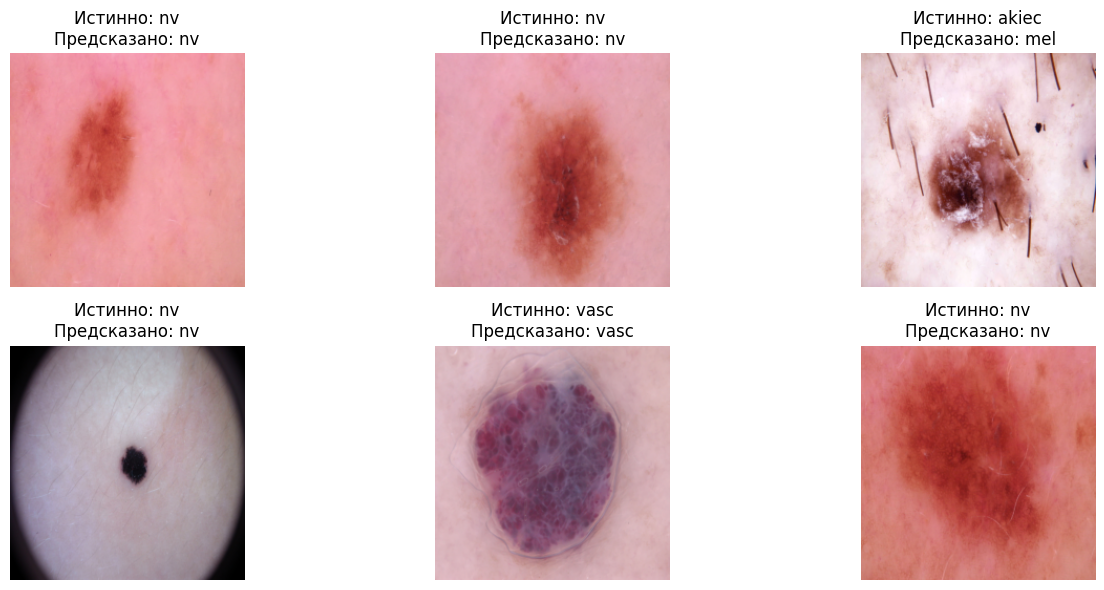

In [ ]:
# Визуализация нескольких предсказаний
inv_norm = transforms.Normalize(mean=[-m/s for m, s in zip([0.485,0.456,0.406],[0.229,0.224,0.225])],
                               std=[1/s for s in [0.229,0.224,0.225]])

def show_predictions(dataset: SkinDataset, preds: np.ndarray, targets: np.ndarray, n: int = 6):
    idxs = np.random.choice(len(dataset), size=n, replace=False)
    fig, axes = plt.subplots(2, n // 2 + n % 2, figsize=(14, 6))
    axes = axes.flatten()
    for ax, idx in zip(axes, idxs):
        image, _ = dataset[idx]
        img = inv_norm(image).permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        true_label = dataset.idx_to_class[targets[idx]]
        pred_label = dataset.idx_to_class[preds[idx]]
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"Истинно: {true_label}\nПредсказано: {pred_label}")
    plt.tight_layout()
    plt.show()

show_predictions(val_dataset, val_preds, val_targets, n=6)


## Кратко, что рассказать
- Задача: многоклассовая классификация дерматоскопических снимков (7 классов), цель — помочь врачу в первичной сортировке.
- Данные: HAM10000, классы несбалансированы ⇒ используем macro-F1 и матрицу ошибок.
- Архитектура: EfficientNet-B0 (предобучен на ImageNet), заменяем последний слой под 7 классов.
- Обучение: аугментации (flip/rotation/color jitter), AdamW + CosineLR, 3–5 эпох для демо.
- Результаты: accuracy + macro-F1, конфьюжн-матрица, примеры картинок с предсказаниями.
- Улучшения: балансировка классов (class weights/oversampling), больше эпох/модель, TTA, Grad-CAM.
